In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel(r'/content/drive/MyDrive/Trabalho Final Setor Publico/Brazil_Policy_Uncertainty_Data.xlsx')
df = df.iloc[:-1]
df.columns = ["year", "month", "EPU_BRA"]

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


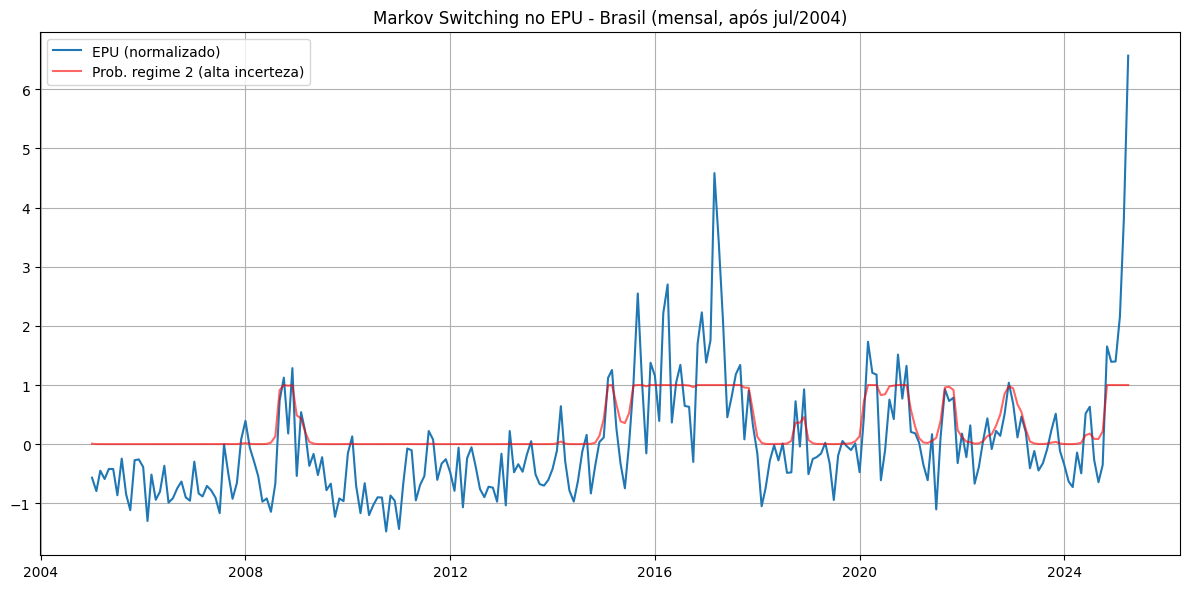

In [3]:
df = df.iloc[:-1]
df["year"] = df["year"].astype(int)
df["Date"] = pd.to_datetime(dict(year=df["year"], month=df["month"], day=1))
df = df[df["Date"] > "2004-12-01"].set_index("Date")

# Normalizar a série mensal
epu_m = df['EPU_BRA']
epu_m_norm = (epu_m - epu_m.mean()) / epu_m.std()

# Estimar modelo Markov Switching mensal
model_m = MarkovRegression(epu_m_norm.dropna(), k_regimes=2, trend='c', switching_variance=True)
result_m = model_m.fit(method='powell', maxiter=1000)

# Obter probabilidades suavizadas do regime 2
smoothed_probs_m = result_m.smoothed_marginal_probabilities[1]

# Plotar resultados mensais
plt.figure(figsize=(12, 6))
plt.plot(epu_m_norm, label='EPU (normalizado)')
plt.plot(smoothed_probs_m, label='Prob. regime 2 (alta incerteza)', color='red', alpha=0.6)
plt.title('Markov Switching no EPU - Brasil (mensal, após jul/2004)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
df

,year,month,EPU_BRA,uncertainty_prob
Date,,,,
2005-01-01,2005,1.0,120.570707,0.007757
2005-02-01,2005,2.0,96.104768,0.001953
2005-03-01,2005,3.0,133.311247,0.001248
2005-04-01,2005,4.0,118.148481,0.001058
2005-05-01,2005,5.0,136.540780,0.001171
...,...,...,...,...
2024-12-01,2024,12.0,332.204146,0.999995
2025-01-01,2025,1.0,332.896237,0.999995
2025-02-01,2025,2.0,415.307382,1.000000


In [8]:
df["uncertainty_prob"] = result_m.smoothed_marginal_probabilities[1]

In [11]:
df.to_excel("/content/drive/MyDrive/uncertainty_prob.xlsx")